In [1]:
!gdown https://drive.google.com/uc?id=1teMMV7lxXotlzYqnt-a8-zn6nVYsYPFZ&export=download
!unzip frames.zip

Downloading...
From: https://drive.google.com/uc?id=1teMMV7lxXotlzYqnt-a8-zn6nVYsYPFZ
To: /content/frames.zip
100% 1.00M/1.00M [00:00<00:00, 124MB/s]
Archive:  frames.zip
   creating: frames/
  inflating: __MACOSX/._frames       
  inflating: frames/.DS_Store        
  inflating: __MACOSX/frames/._.DS_Store  
   creating: frames/imgs/
  inflating: __MACOSX/frames/._imgs  
   creating: frames/bg/
   creating: frames/masks/
  inflating: __MACOSX/frames/._masks  
  inflating: frames/imgs/110020220086_01.png  
  inflating: __MACOSX/frames/imgs/._110020220086_01.png  
  inflating: frames/imgs/110020220079_01.png  
  inflating: __MACOSX/frames/imgs/._110020220079_01.png  
  inflating: frames/imgs/110020234383_01.png  
  inflating: __MACOSX/frames/imgs/._110020234383_01.png  
  inflating: frames/imgs/190605067703_01.png  
  inflating: __MACOSX/frames/imgs/._190605067703_01.png  
  inflating: frames/imgs/190605021125_01.png  
  inflating: __MACOSX/frames/imgs/._190605021125_01.png  
  inflatin

In [2]:
# imports

from skimage import io
from skimage.io import imsave
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import laplace

In [3]:
# main function

# makes poisson blend of partiular channel of the image
# iter: represent amount of iterations for poisson computation
# the higher iter is, the better quality is the blend, but also the longer it takes to compute one image

# example speeds:
# input: image resolution = 1486x1486, iter = 2048 iteration per channel , computed at 3 channels
# time: tool 1 minute 11 seconds on T4 GPU

def poisson_blend(target_img, src_img, mask_img, iter: int = 2048):
    for i in range(iter):
        if i % 100 == 0:
          print(f"conducted {i} iterations")
        target_img = target_img + 0.25 * mask_img * laplace(target_img - src_img)
    return target_img.clip(0, 1)

In [6]:
# load images

src_img = io.imread("/content/frames/imgs/110020220079_01.png",) / 255.0
target_img = io.imread("/content/frames/bg/bg_1.jpg",) / 255.0
mask_img = io.imread("/content/frames/masks/110020220079_01.png")
mask_img = mask_img.astype(int)
#print(np.unique(mask_img))

In [7]:
# convert to same shape

target_img = cv2.resize(target_img, (src_img.shape[1], src_img.shape[0]))
mask_img = cv2.resize(mask_img, (src_img.shape[1], src_img.shape[0]))

print(src_img.shape)
print(target_img.shape)
print(mask_img.shape)

(1486, 1486, 3)
(1486, 1486, 3)
(1486, 1486)


In [8]:
# Extract the region of interest (ROI) from the mask and source image based on the mask's coordinates


src_coords = np.argwhere(mask_img)
#print(src_coords)
src_top, src_left = np.min(src_coords, axis=0) - 1
src_bottom, src_right = np.max(src_coords, axis=0) + 1
mask_patch = mask_img[src_top : src_bottom + 1, src_left : src_right + 1]
src_patch = src_img[src_top : src_bottom + 1, src_left : src_right + 1]

In [9]:
# Calculate the target patch's coordinates and extract the corresponding region from the target image

target_top, target_left = (src_top + target_img.shape[0] - src_img.shape[0], 30)
target_bottom, target_right = (
    target_top + mask_patch.shape[0],
    target_left + mask_patch.shape[1],
)
target_patch = target_img[target_top:target_bottom, target_left:target_right]

In [10]:
# perform poisson blend for each color channel separately

blend_patch = np.stack(
    [
        poisson_blend(target_patch[:, :, i], src_patch[:, :, i], mask_patch)
        for i in range(3) # i = 0 for red, i = 1 for green, i = 2 for blue
    ],
    axis=2,
)

conducted 0 iterations
conducted 100 iterations
conducted 200 iterations
conducted 300 iterations
conducted 400 iterations
conducted 500 iterations
conducted 600 iterations
conducted 700 iterations
conducted 800 iterations
conducted 900 iterations
conducted 1000 iterations
conducted 1100 iterations
conducted 1200 iterations
conducted 1300 iterations
conducted 1400 iterations
conducted 1500 iterations
conducted 1600 iterations
conducted 1700 iterations
conducted 1800 iterations
conducted 1900 iterations
conducted 2000 iterations
conducted 0 iterations
conducted 100 iterations
conducted 200 iterations
conducted 300 iterations
conducted 400 iterations
conducted 500 iterations
conducted 600 iterations
conducted 700 iterations
conducted 800 iterations
conducted 900 iterations
conducted 1000 iterations
conducted 1100 iterations
conducted 1200 iterations
conducted 1300 iterations
conducted 1400 iterations
conducted 1500 iterations
conducted 1600 iterations
conducted 1700 iterations
conducted 

<ipython-input-11-77b1c204b773>:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(src_patch)
<ipython-input-11-77b1c204b773>:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(target_patch)
<ipython-input-11-77b1c204b773>:9: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(blend_patch)


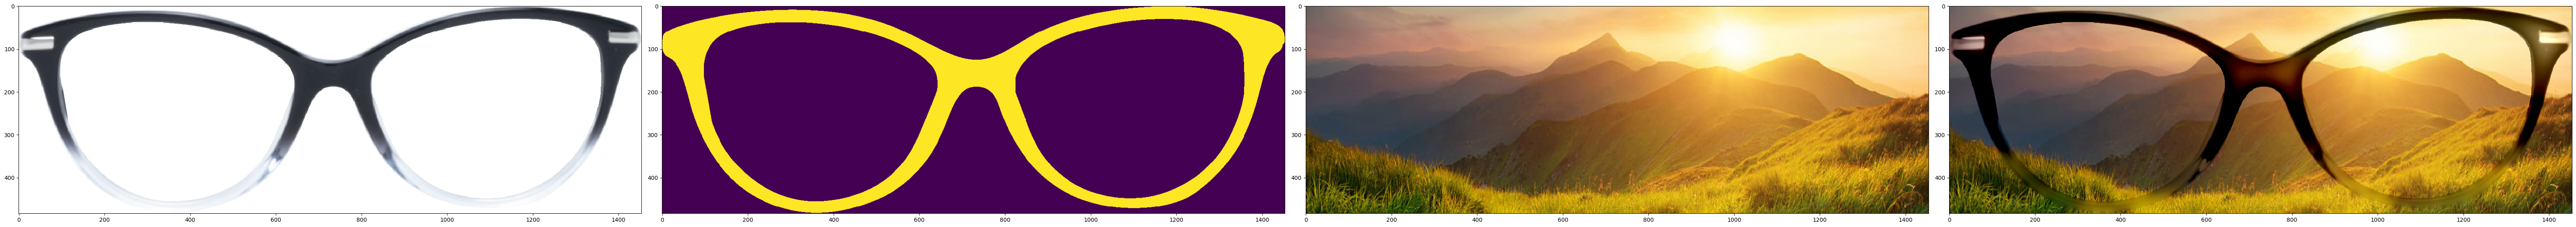

In [11]:
plt.figure(figsize=(64, 64))
plt.subplot(1, 4, 1)
io.imshow(src_patch)
plt.subplot(1, 4, 2)
plt.imshow(mask_patch)
plt.subplot(1, 4, 3)
io.imshow(target_patch)
plt.subplot(1, 4, 4)
io.imshow(blend_patch)
plt.show()

In [12]:
# Save the blend_patch image
print(np.shape(blend_patch))
from PIL import Image
import numpy as np

# Convert to uint8 if necessary
blend_patch_uint8 = (blend_patch * 255).astype(np.uint8)

# Save the blended patch as an image
image = Image.fromarray(blend_patch_uint8)
image.save("poisson_blending.jpg")


(484, 1454, 3)
